# Machine Learning Report — Linear Regression for Real Estate Price Prediction

This notebook was prepared as a complete foundation for a detailed report. The idea is not just to show the final result, but to demonstrate why every decision in data processing, encoding, target variable transformation, and model selection was justified.

The focus is on linear models and the MAPE error, since that is the metric relevant to the task. The final model is a Ridge regression in a pipeline with Target Encoding, a RobustScaler, and a log-transformation of the target variable.

In [1]:
# ==============================
# 0. Import libraries
# ==============================

import os
import re
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.metrics import mean_absolute_percentage_error, make_scorer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import RobustScaler, StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

## 1. Loading the data

In this part I load the training and test sets. The training set contains the target variable `Cena`, while the test set may or may not include the price, depending on whether it's meant for local validation or for the final submission.

If the files are not in the same folder as the notebook, the paths need to be changed in the next cell.

In [2]:
# ==============================
# 1. File paths
# ==============================

TRAIN_PATH = 'train.json'
TEST_PATH = 'test.json'

# If the files have different names, change the two variables above.

train = pd.read_json(TRAIN_PATH)
test = pd.read_json(TEST_PATH)

print('Train shape:', train.shape)
print('Test shape:', test.shape)
display(train.head())

Train shape: (2096, 11)
Test shape: (5, 11)


,Slike,Cena,Naziv,Grad,Kvadratura,Sobe,Sprat,Prodavac,Uknjizen,Garaza,Parking
0,9,150000,Crveni Krst Vračar,Beograd,48,2.0,7,Agencija,Da,Ne,Da
1,12,197200,Stevana Sremca,Niš,91,3.5,prizemlje,Agencija,Da,Da,Ne
2,16,215600,Petrovaradin,Novi Sad,98,4.0,1,Agencija,Da,Ne,Ne
3,10,126200,Trg kralja Aleksandra Ujedinitelja,Niš,72,3.0,2,Agencija,Da,Ne,Da
4,1,1,Ugao Partizanskih baza i Gutenbergove,Subotica,66,3.0,1,Investitor,Da,Ne,Ne


## 2. Basic structure of the dataset

Before any modeling, I check the column types, the number of missing values, and basic statistics. This matters because regression models require numeric, clean, and consistently formatted input.

In [3]:
print('Column information:')
train.info()

print('\nNumber of duplicates:', train.duplicated().sum())

missing = pd.DataFrame({
    'missing_count': train.isna().sum(),
    'missing_percent': train.isna().mean() * 100
}).sort_values('missing_count', ascending=False)

display(missing)
display(train.describe(include='all').T)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2096 entries, 0 to 2095
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Slike       2096 non-null   object 
 1   Cena        2096 non-null   int64  
 2   Naziv       2096 non-null   object 
 3   Grad        2096 non-null   object 
 4   Kvadratura  2096 non-null   int64  
 5   Sobe        2096 non-null   float64
 6   Sprat       2096 non-null   object 
 7   Prodavac    2096 non-null   object 
 8   Uknjizen    2096 non-null   object 
 9   Garaza      2096 non-null   object 
 10  Parking     2096 non-null   object 
dtypes: float64(1), int64(2), object(8)
memory usage: 180.3+ KB

Number of duplicates: 342


,missing_count,missing_percent
Slike,0,0.0
Cena,0,0.0
Naziv,0,0.0
Grad,0,0.0
Kvadratura,0,0.0
Sobe,0,0.0
Sprat,0,0.0
Prodavac,0,0.0
Uknjizen,0,0.0
Garaza,0,0.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Slike,2096.0,63.0,1.0,262.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cena,2096.0,NaN,NaN,NaN,181505.375954,233250.377886,1.0,95140.25,147000.0,210000.0,5187757.0
Naziv,2096,695,Crveni Krst,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Grad,2096,5,Beograd,753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Kvadratura,2096.0,NaN,NaN,NaN,66.849237,32.722981,16.0,45.0,61.0,79.0,330.0
Sobe,2096.0,NaN,NaN,NaN,2.528626,1.118574,0.5,2.0,2.5,3.0,20.0
Sprat,2096,26,1,458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Prodavac,2096,3,Agencija,1855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Uknjizen,2096,2,Da,1383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Garaza,2096,2,Ne,1774,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Detecting hidden issues in numeric columns

The standard `isna()` is often not enough, since some numeric columns can contain empty strings or text values. That's why I force every numeric-like column to convert to a number using `pd.to_numeric(errors='coerce')`. Anything that cannot be converted to a number becomes `NaN`, so the real data quality becomes visible.

In [4]:
NUMERIC_LIKE_COLUMNS = ['Cena', 'Kvadratura', 'Sobe', 'Slike']

hidden_issues = []
for col in NUMERIC_LIKE_COLUMNS:
    if col in train.columns:
        converted = pd.to_numeric(train[col], errors='coerce')
        hidden_issues.append({
            'column': col,
            'NaN before conversion': train[col].isna().sum(),
            'NaN after to_numeric': converted.isna().sum(),
            'newly discovered issues': converted.isna().sum() - train[col].isna().sum(),
            'examples of problematic values': train.loc[converted.isna() & train[col].notna(), col].astype(str).unique()[:10].tolist()
        })

hidden_issues_df = pd.DataFrame(hidden_issues)
display(hidden_issues_df)

,column,NaN before conversion,NaN after to_numeric,newly discovered issues,examples of problematic values
0,Cena,0,0,0,[]
1,Kvadratura,0,0,0,[]
2,Sobe,0,0,0,[]
3,Slike,0,5,5,[]


## 4. Exploratory analysis of the target variable `Cena`

The property price is the target variable. Real estate prices often show strong right skew: most listings fall within a realistic price range, while a smaller number of luxury or incorrectly entered listings create a long tail. This can hurt linear regression because extreme values have too much influence on error minimization.

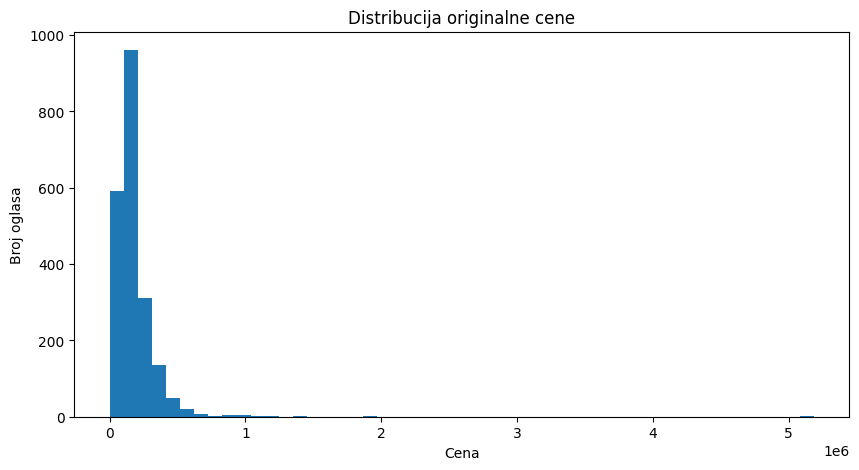

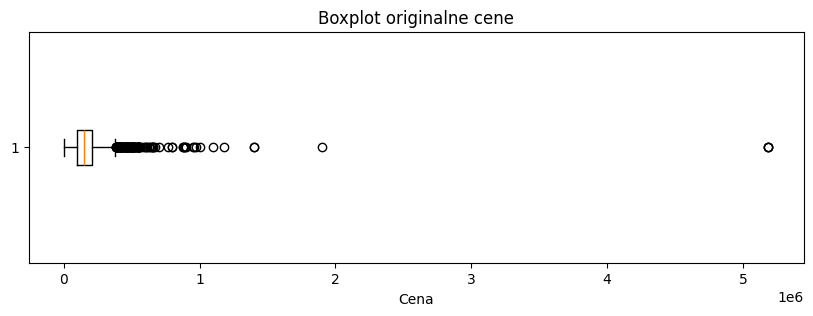

Skewness of the original price: 14.831387385292897
Kurtosis of the original price: 304.9029705807986


In [5]:
def to_num(series, fill=None):
    s = pd.to_numeric(series, errors='coerce')
    return s.fillna(fill) if fill is not None else s

eda = train.copy()
for col in NUMERIC_LIKE_COLUMNS:
    if col in eda.columns:
        eda[col] = to_num(eda[col])

fig = plt.figure(figsize=(10, 5))
plt.hist(eda['Cena'].dropna(), bins=50)
plt.title('Distribution of the original price')
plt.xlabel('Cena')
plt.ylabel('Number of listings')
plt.show()

fig = plt.figure(figsize=(10, 3))
plt.boxplot(eda['Cena'].dropna(), vert=False)
plt.title('Boxplot of the original price')
plt.xlabel('Cena')
plt.show()

print('Skewness of the original price:', eda['Cena'].skew())
print('Kurtosis of the original price:', eda['Cena'].kurtosis())

## 5. Log-transformation of the price

Because of the right-skewed distribution, I use `np.log1p(Cena)`. This compresses extremely large values and the distribution becomes more suitable for linear models. It's important that in the final model the prediction is transformed back using `np.expm1`, so that the result is again expressed in euros.

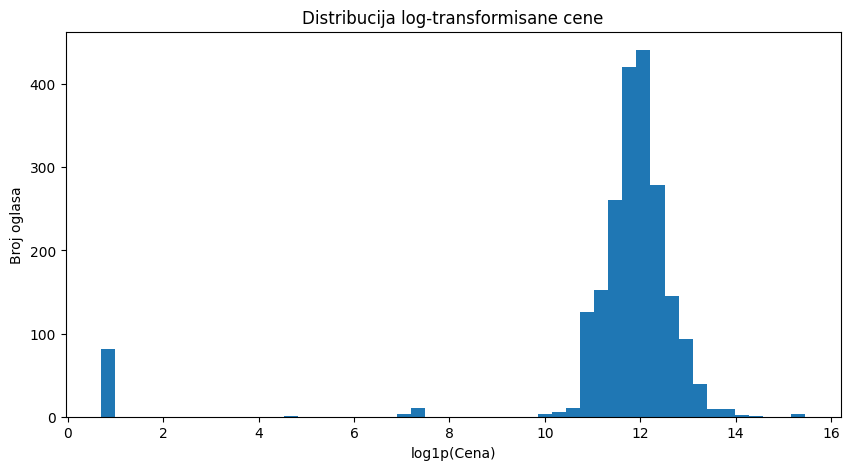

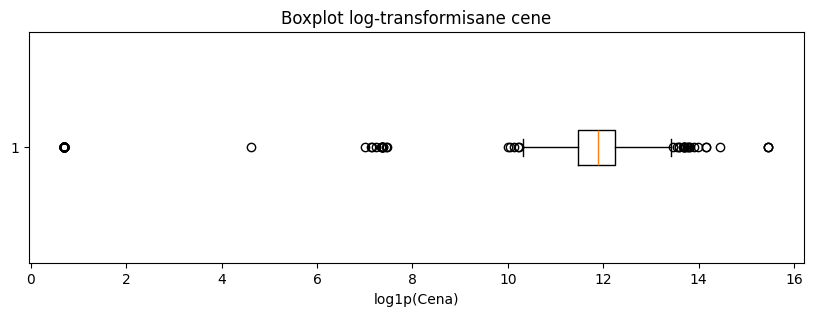

Skewness of the log price: -4.08581441211277
Kurtosis of the log price: 16.466367812985048


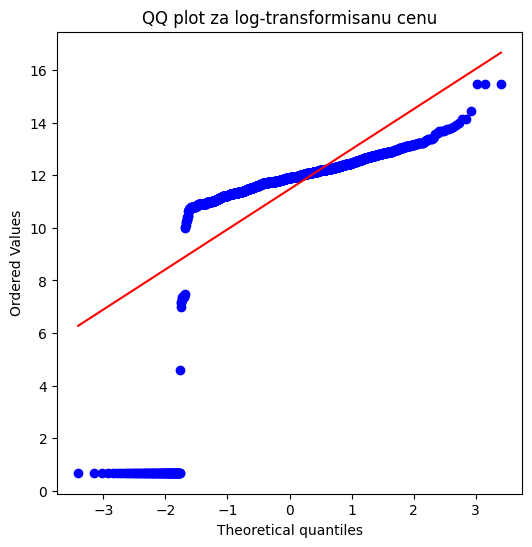

In [6]:
eda['Log_Cena'] = np.log1p(eda['Cena'])

fig = plt.figure(figsize=(10, 5))
plt.hist(eda['Log_Cena'].dropna(), bins=50)
plt.title('Distribution of the log-transformed price')
plt.xlabel('log1p(Cena)')
plt.ylabel('Number of listings')
plt.show()

fig = plt.figure(figsize=(10, 3))
plt.boxplot(eda['Log_Cena'].dropna(), vert=False)
plt.title('Boxplot of the log-transformed price')
plt.xlabel('log1p(Cena)')
plt.show()

print('Skewness of the log price:', eda['Log_Cena'].skew())
print('Kurtosis of the log price:', eda['Log_Cena'].kurtosis())

fig = plt.figure(figsize=(6, 6))
stats.probplot(eda['Log_Cena'].dropna(), dist='norm', plot=plt)
plt.title('QQ plot for the log-transformed price')
plt.show()

## 6. Relationship between price and basic numeric attributes

The first expected predictor of price is the floor area (`Kvadratura`). However, floor area alone cannot explain the entire price, since price is strongly influenced by the city, micro-location, apartment condition, parking/garage, floor, and other attributes.

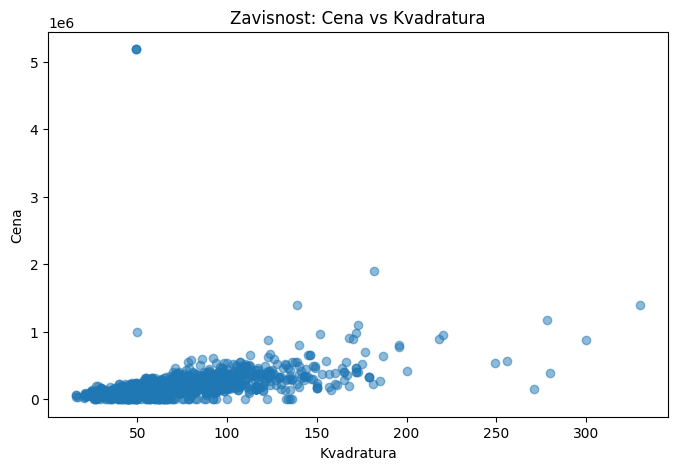

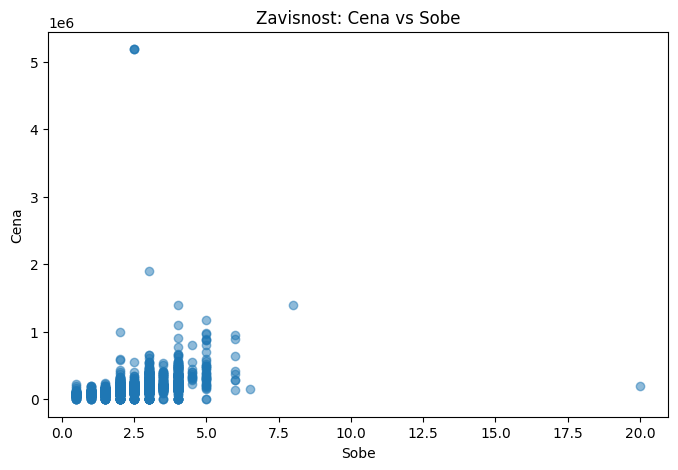

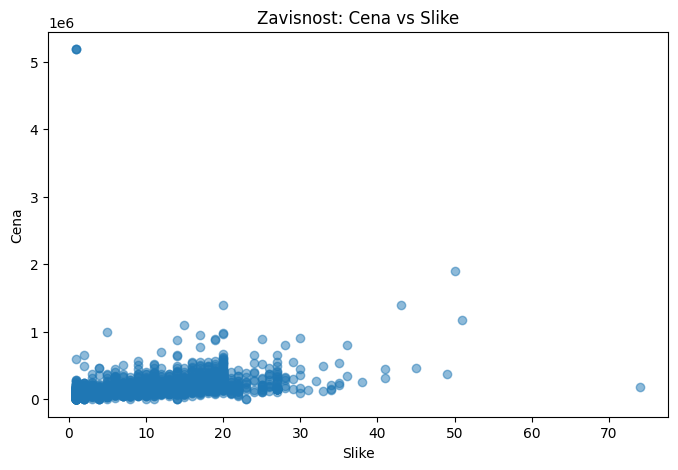

,Cena,Kvadratura,Sobe,Slike
Cena,1.000000,0.382866,0.299304,0.251532
Kvadratura,0.382866,1.000000,0.782738,0.432109
Sobe,0.299304,0.782738,1.000000,0.365698
Slike,0.251532,0.432109,0.365698,1.000000


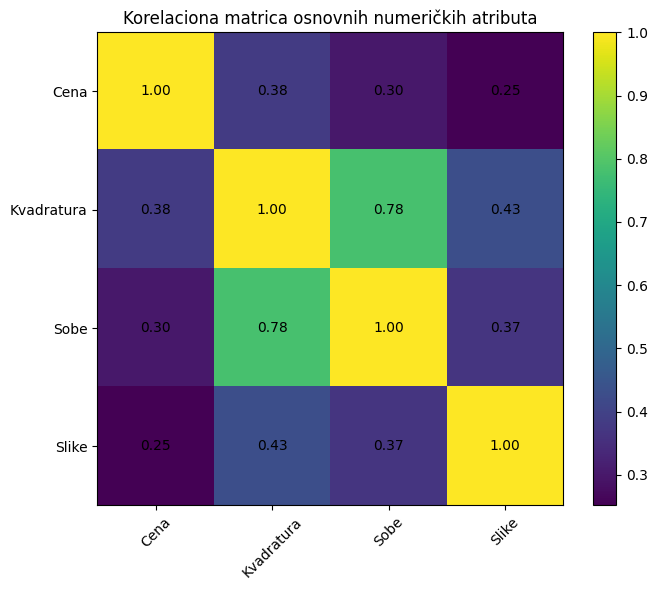

In [7]:
base_numeric = ['Cena', 'Kvadratura', 'Sobe', 'Slike']

for xcol in ['Kvadratura', 'Sobe', 'Slike']:
    if xcol in eda.columns:
        fig = plt.figure(figsize=(8, 5))
        plt.scatter(eda[xcol], eda['Cena'], alpha=0.5)
        plt.title(f'Relationship: Cena vs {xcol}')
        plt.xlabel(xcol)
        plt.ylabel('Cena')
        plt.show()

corr_cols = [c for c in base_numeric if c in eda.columns]
corr = eda[corr_cols].corr()
display(corr)

fig = plt.figure(figsize=(7, 6))
plt.imshow(corr, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Correlation matrix of basic numeric attributes')
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
plt.tight_layout()
plt.show()

## 7. Outlier analysis and removal

Outliers can significantly shift the coefficients of linear models. That's why I use three filters:

1. `Cena > 15000` — removes unrealistically cheap listings.
2. `Cena po m²` (price per m²) between 500 and 8000 — removes unrealistic price-to-area ratios.
3. `abs(zscore(log1p(Cena))) < 3` — removes statistically extreme values in the log-transformed space.

These filters are not arbitrary — they are directly based on business logic and statistical control of extreme values.

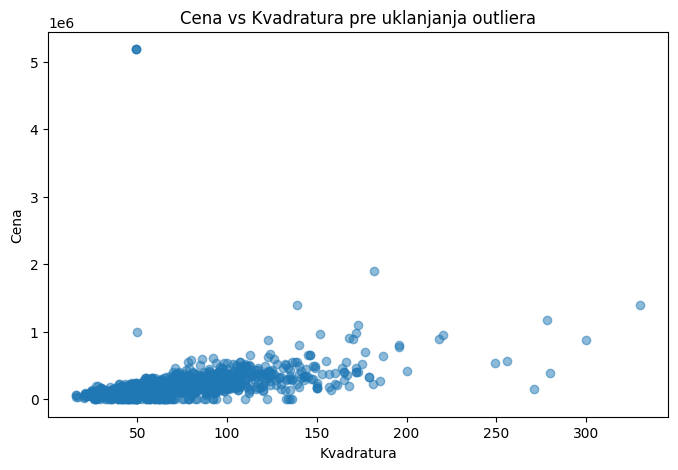

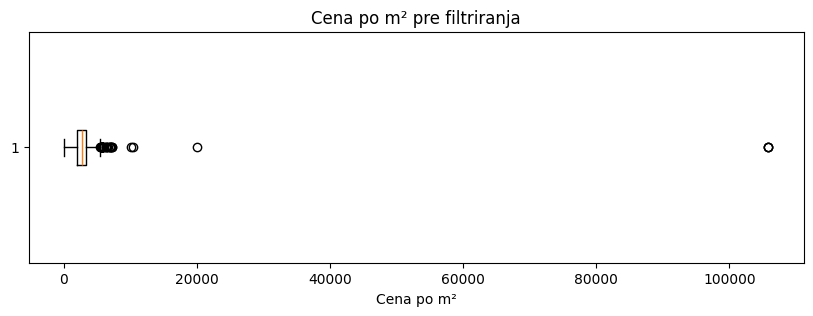

Number of rows before cleaning: 1754
Number of rows after dropna: 1754
Number of rows after outlier filtering: 1658
Number of rows removed by outlier filtering: 96


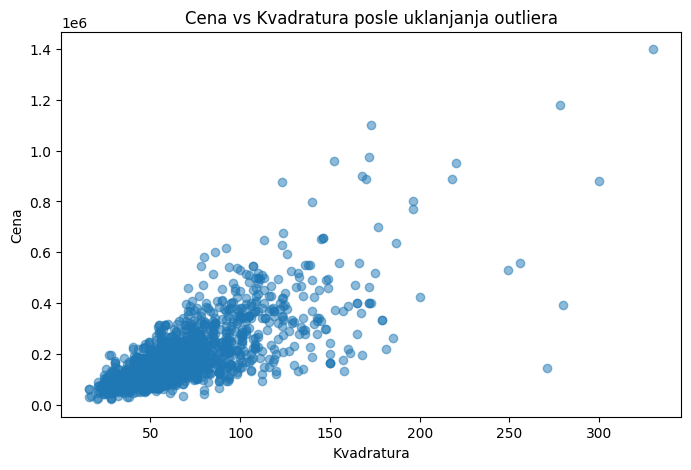

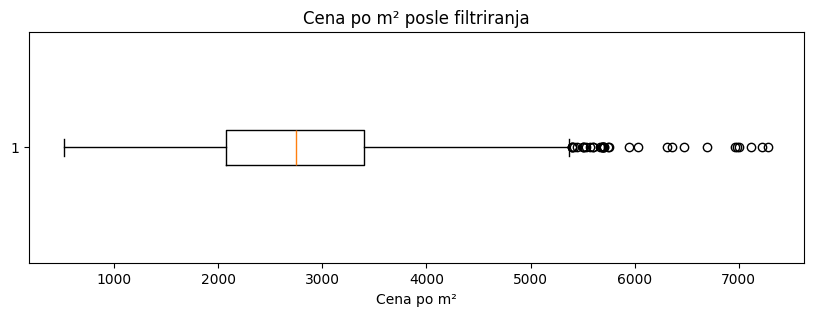

In [8]:
cleaning_demo = train.copy().drop_duplicates()
cleaning_demo['Cena'] = to_num(cleaning_demo['Cena'])
cleaning_demo['Kvadratura'] = to_num(cleaning_demo['Kvadratura'])
cleaning_demo['Sobe'] = to_num(cleaning_demo['Sobe'])

before_rows = len(cleaning_demo)
cleaning_demo = cleaning_demo.dropna(subset=['Cena', 'Kvadratura', 'Sobe'])
cleaning_demo['m2_temp'] = cleaning_demo['Cena'] / cleaning_demo['Kvadratura']

fig = plt.figure(figsize=(8, 5))
plt.scatter(cleaning_demo['Kvadratura'], cleaning_demo['Cena'], alpha=0.5)
plt.title('Cena vs Kvadratura before outlier removal')
plt.xlabel('Kvadratura')
plt.ylabel('Cena')
plt.show()

fig = plt.figure(figsize=(10, 3))
plt.boxplot(cleaning_demo['m2_temp'].replace([np.inf, -np.inf], np.nan).dropna(), vert=False)
plt.title('Price per m² before filtering')
plt.xlabel('Price per m²')
plt.show()

filtered = cleaning_demo[
    (cleaning_demo['Cena'] > 15000) &
    (cleaning_demo['m2_temp'].between(500, 8000)) &
    (np.abs(stats.zscore(np.log1p(cleaning_demo['Cena']))) < 3)
].copy()

after_rows = len(filtered)
print('Number of rows before cleaning:', before_rows)
print('Number of rows after dropna:', len(cleaning_demo))
print('Number of rows after outlier filtering:', after_rows)
print('Number of rows removed by outlier filtering:', len(cleaning_demo) - after_rows)

fig = plt.figure(figsize=(8, 5))
plt.scatter(filtered['Kvadratura'], filtered['Cena'], alpha=0.5)
plt.title('Cena vs Kvadratura after outlier removal')
plt.xlabel('Kvadratura')
plt.ylabel('Cena')
plt.show()

fig = plt.figure(figsize=(10, 3))
plt.boxplot(filtered['m2_temp'].dropna(), vert=False)
plt.title('Price per m² after filtering')
plt.xlabel('Price per m²')
plt.show()

## 8. Preprocessing functions

Below I define the same principles used by the final pipeline. It's crucial that any values “learned” from the data, such as medians, are computed exclusively on the training set. This prevents data leakage.

In [9]:
def map_floor(f):
    f = str(f).lower().strip()
    if any(x in f for x in ['prizemlje', 'vpr', '0', 'nisko prizemlje']):
        return 0.0
    if any(x in f for x in ['suteren', '-1']):
        return -1.0
    if any(x in f for x in ['potkrovlje', 'pk']):
        return 10.0
    try:
        v = float(f)
        return v if v <= 30 else 3.0
    except:
        return 1.0


def preprocess(df, medians):
    d = df.copy()

    d['Kvadratura'] = to_num(d['Kvadratura'], medians['area'])
    d['Sobe'] = to_num(d['Sobe'], medians['rooms'])
    d['Slike'] = to_num(d['Slike'], medians['images'])

    d['Log_Kvadratura'] = np.log1p(d['Kvadratura'])
    d['Area_per_Room'] = d['Kvadratura'] / (d['Sobe'] + 0.1)

    for col in ['Uknjizen', 'Garaza', 'Parking']:
        if col in d:
            d[col] = d[col].map({'Da': 1, 'Ne': 0}).fillna(0)

    if {'Garaza', 'Parking'}.issubset(d.columns):
        d['Ima_Parking_Ili_Garazu'] = ((d['Garaza'] == 1) | (d['Parking'] == 1)).astype(int)

    n = d['Naziv'].astype(str).str.lower().fillna('')
    d['Lux'] = n.str.contains('lux|luks|novo|premium|hram|bw|vodi|dedinj|senjak|salonac|smart', regex=True).astype(int)
    d['Renoviranje'] = n.str.contains('izvorno|renovir|hitno|suteren|ulaganj|stara|adaptacija', regex=True).astype(int)

    d['Sprat_Num'] = d['Sprat'].apply(map_floor).fillna(medians['floor'])
    d['Je_Prizemlje'] = (d['Sprat_Num'] == 0).astype(int)
    d['Je_Suteren'] = (d['Sprat_Num'] == -1).astype(int)

    if 'Prodavac' in d:
        d['Je_Investitor'] = (d['Prodavac'].astype(str).str.lower() == 'investitor').astype(int)

    d['Lokacija_Spojeno'] = d['Grad'].astype(str) + '_' + d['Naziv'].astype(str)

    d = d.drop(columns=['Naziv', 'Sprat', 'Prodavac', 'm2_temp'], errors='ignore')
    d = pd.get_dummies(d, columns=['Grad'], drop_first=True)

    for col in d.columns:
        if col not in ['Cena', 'Lokacija_Spojeno']:
            d[col] = to_num(d[col], 0)

    return d

## 9. Preprocessing the training set

Here you can see the complete data processing flow: removing duplicates, converting numeric columns, dropping rows without key values, outlier filtering, and preparing medians to fill in missing values.

In [10]:
train_clean = train.copy().drop_duplicates()

train_clean['Kvadratura'] = to_num(train_clean['Kvadratura'])
train_clean['Sobe'] = to_num(train_clean['Sobe'])
train_clean['Cena'] = to_num(train_clean['Cena'])
train_clean = train_clean.dropna(subset=['Cena', 'Kvadratura', 'Sobe'])

train_clean['m2_temp'] = train_clean['Cena'] / train_clean['Kvadratura']
train_clean = train_clean[
    (train_clean['Cena'] > 15000) &
    (train_clean['m2_temp'].between(500, 8000)) &
    (np.abs(stats.zscore(np.log1p(train_clean['Cena']))) < 3)
].copy()

medians = {
    'images': to_num(train_clean['Slike']).median(),
    'area': train_clean['Kvadratura'].median(),
    'rooms': train_clean['Sobe'].median(),
    'floor': train_clean['Sprat'].apply(map_floor).median()
}

print('Medians learned from the training set:')
print(medians)

train_p = preprocess(train_clean, medians)
test_p = preprocess(test, medians)

print('Train processed shape:', train_p.shape)
print('Test processed shape:', test_p.shape)
display(train_p.head())

Medians learned from the training set:
{'images': np.float64(11.0), 'area': np.float64(60.5), 'rooms': np.float64(2.5), 'floor': np.float64(2.0)}
Train processed shape: (1658, 21)
Test processed shape: (5, 21)


,Slike,Cena,Kvadratura,Sobe,Uknjizen,Garaza,Parking,Log_Kvadratura,Area_per_Room,Ima_Parking_Ili_Garazu,Lux,Renoviranje,Sprat_Num,Je_Prizemlje,Je_Suteren,Je_Investitor,Lokacija_Spojeno,Grad_Kruševac,Grad_Niš,Grad_Novi Sad,Grad_Subotica
0,9.0,150000,48,2.0,1,0,1,3.891820,22.857143,1,0,0,7.0,0,0,0,Beograd_Crveni Krst Vračar,False,False,False,False
1,12.0,197200,91,3.5,1,1,0,4.521789,25.277778,1,0,0,0.0,1,0,0,Niš_Stevana Sremca,False,True,False,False
2,16.0,215600,98,4.0,1,0,0,4.595120,23.902439,0,0,0,1.0,0,0,0,Novi Sad_Petrovaradin,False,False,True,False
3,10.0,126200,72,3.0,1,0,1,4.290459,23.225806,1,0,0,2.0,0,0,0,Niš_Trg kralja Aleksandra Ujedinitelja,False,True,False,False
5,4.0,45380,25,0.5,1,0,0,3.258097,41.666667,0,0,0,0.0,1,0,0,Novi Sad_Braće Grim,False,False,True,False


## 10. Justification for feature engineering

The new attributes were not added randomly. Each one has a business or statistical rationale:

- `Log_Kvadratura` softens the influence of extremely large floor areas.
- `Area_per_Room` describes how functional the layout is.
- `Lux` picks up textual signals about premium properties.
- `Renoviranje` picks up signals about condition that can lower the price.
- `Je_Prizemlje` and `Je_Suteren` isolate floors that often have a specific effect on price.
- `Ima_Parking_Ili_Garazu` compresses two similar pieces of information into one useful variable.

,correlation_with_price
Cena,1.000000
Log_Kvadratura,0.699599
Area_per_Room,0.212649
Sprat_Num,0.186470
Ima_Parking_Ili_Garazu,0.176355
Lux,0.088660
Renoviranje,-0.033892
Je_Investitor,-0.062859
Je_Suteren,-0.073743
Je_Prizemlje,-0.105475


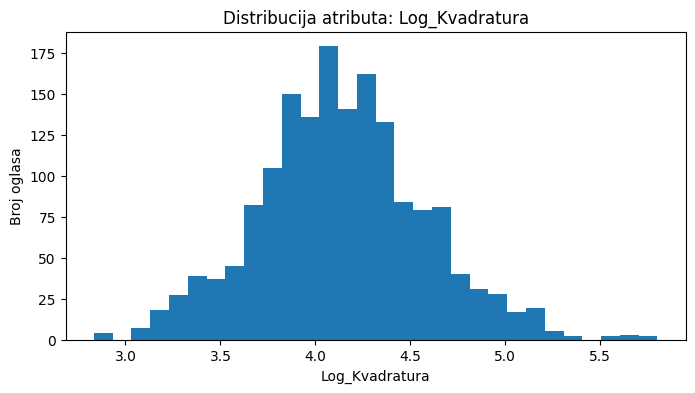

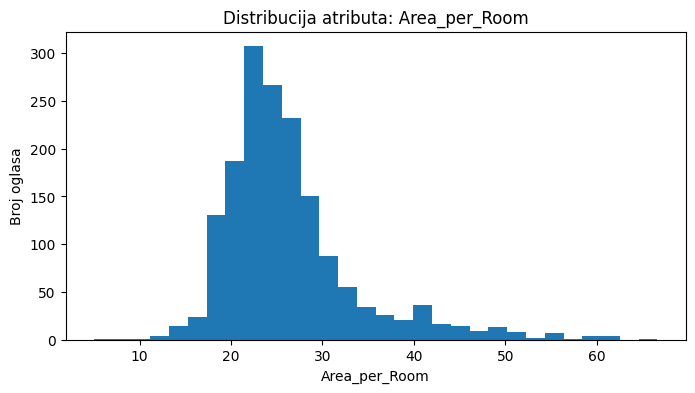

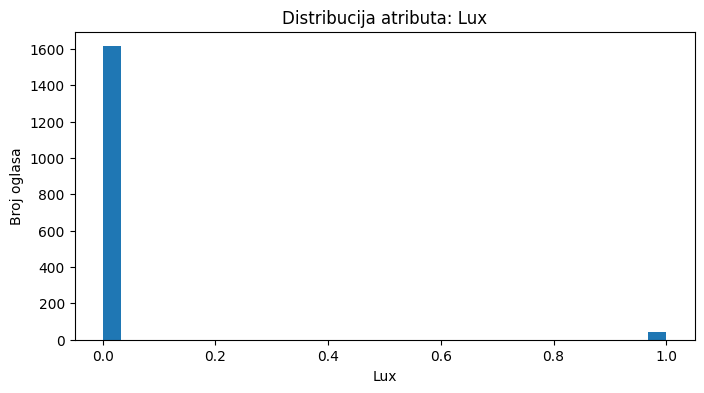

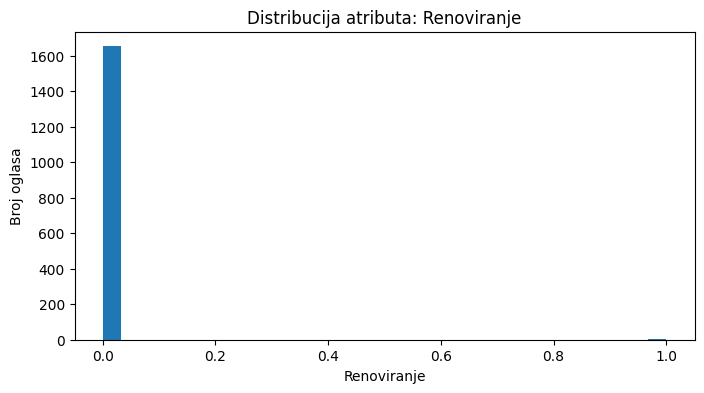

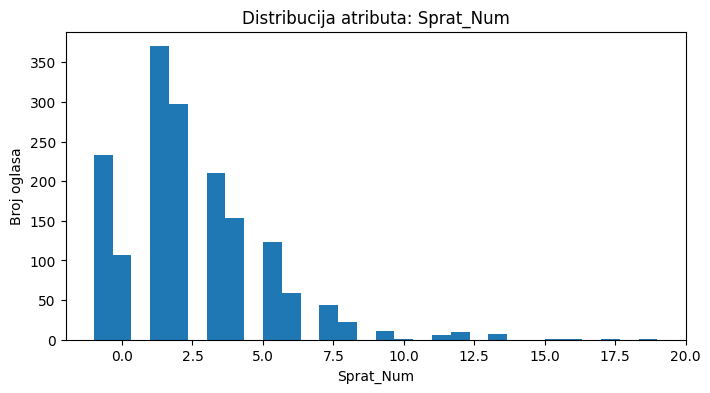

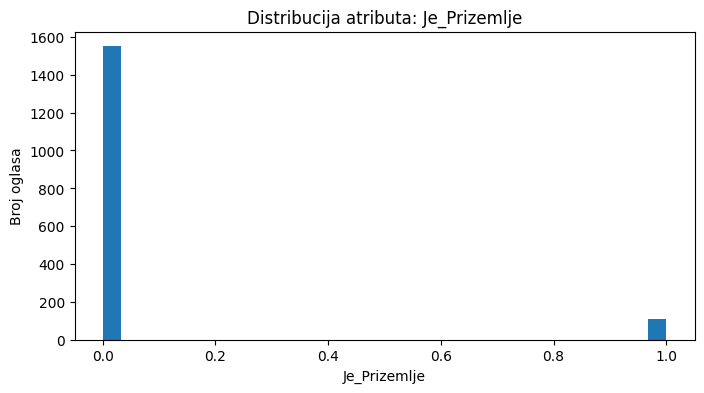

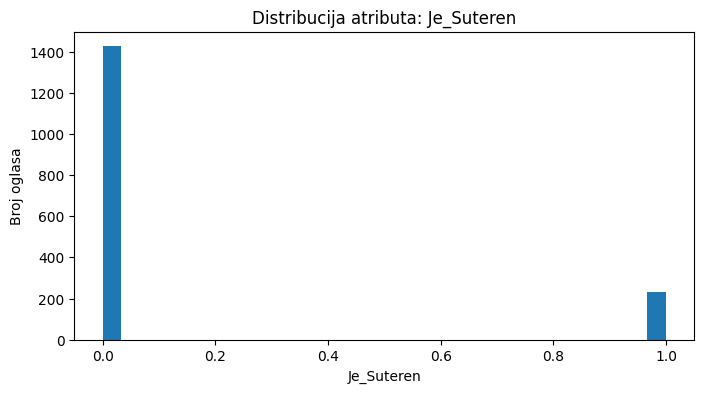

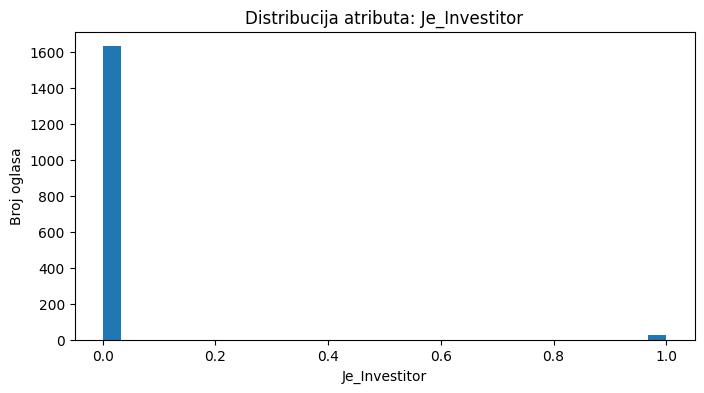

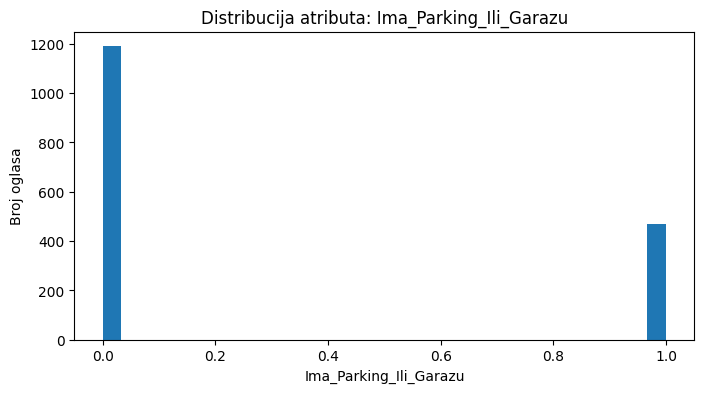

,count,mean,median
Lux,,,
0,1614,190305.151797,158700.0
1,44,262020.795455,170225.0


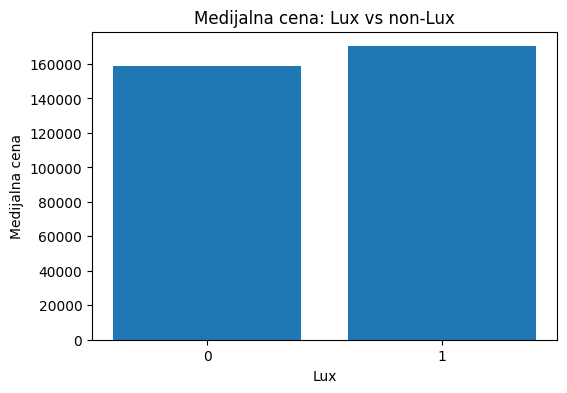

,count,mean,median
Renoviranje,,,
0,1653,192450.683606,159650.0
1,5,112090.000000,112000.0


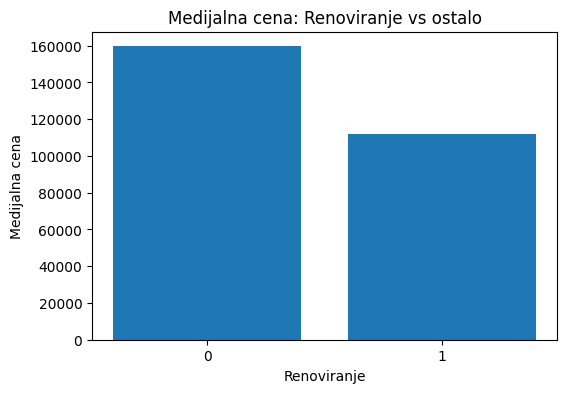

In [11]:
engineered_cols = ['Log_Kvadratura', 'Area_per_Room', 'Lux', 'Renoviranje', 'Sprat_Num', 'Je_Prizemlje', 'Je_Suteren', 'Je_Investitor', 'Ima_Parking_Ili_Garazu']
existing_engineered = [c for c in engineered_cols if c in train_p.columns]

corr_with_target = train_p[['Cena'] + existing_engineered].corr()['Cena'].sort_values(ascending=False)
display(corr_with_target.to_frame('correlation_with_price'))

for col in existing_engineered:
    fig = plt.figure(figsize=(8, 4))
    plt.hist(train_p[col].dropna(), bins=30)
    plt.title(f'Distribution of attribute: {col}')
    plt.xlabel(col)
    plt.ylabel('Number of listings')
    plt.show()

if 'Lux' in train_p.columns:
    lux_stats = train_p.groupby('Lux')['Cena'].agg(['count', 'mean', 'median'])
    display(lux_stats)
    fig = plt.figure(figsize=(6, 4))
    plt.bar(lux_stats.index.astype(str), lux_stats['median'])
    plt.title('Median price: Lux vs non-Lux')
    plt.xlabel('Lux')
    plt.ylabel('Median price')
    plt.show()

if 'Renoviranje' in train_p.columns:
    ren_stats = train_p.groupby('Renoviranje')['Cena'].agg(['count', 'mean', 'median'])
    display(ren_stats)
    fig = plt.figure(figsize=(6, 4))
    plt.bar(ren_stats.index.astype(str), ren_stats['median'])
    plt.title('Median price: Renoviranje vs other')
    plt.xlabel('Renoviranje')
    plt.ylabel('Median price')
    plt.show()

## 11. Justification for the encoding choice

`Grad` has a small number of categories, so it's well suited to One-Hot Encoding. `Lokacija_Spojeno`, on the other hand, has a large number of possible values since it combines the city and the location name. Using One-Hot Encoding for that would create a huge number of sparse columns, which would make life harder for linear models.

Target Encoding solves this problem by turning a category into a single numeric value tied to the target's average behavior. Important: this doesn't make the model non-linear. Encoding is just a transformation of the input column into a number. The model that then learns the relationship between the attributes and the price is still a linear model — in this case, Ridge regression.

To avoid data leakage, the TargetEncoder sits inside the sklearn Pipeline and is computed only on the training fold during cross-validation.

Number of unique cities: 5
Number of unique combined locations: 709


,listing_count
Novi Sad_Telep,51
Kruševac_Gradske lokacije,47
Novi Sad_Novi Sad - Centar,34
Novi Sad_Bulevar Oslobođenja,30
Novi Sad_Adice,29
Novi Sad_Detelinara,26
Novi Sad_Petrovaradin,23
Subotica_Centar,23
Novi Sad_Novo Naselje,22
Kruševac_Centar,21


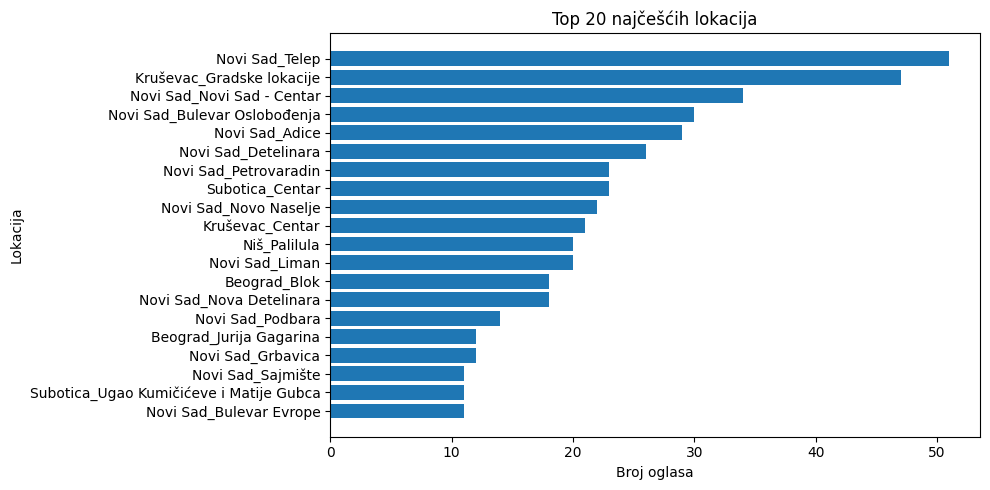

,listing_count,median_price,median_price_per_m2
Lokacija_Spojeno,,,
Novi Sad_Telep,51,129000.0,2700.000000
Kruševac_Gradske lokacije,47,98000.0,1492.307692
Novi Sad_Novi Sad - Centar,34,176375.0,3294.047619
Novi Sad_Bulevar Oslobođenja,30,166000.0,2886.450268
Novi Sad_Adice,29,116600.0,2000.000000
Novi Sad_Detelinara,26,129908.0,2953.105263
Novi Sad_Petrovaradin,23,153070.0,2223.863636
Subotica_Centar,23,125000.0,1609.523810
Novi Sad_Novo Naselje,22,129375.0,2577.718703


In [12]:
print('Number of unique cities:', train_clean['Grad'].nunique())
print('Number of unique combined locations:', (train_clean['Grad'].astype(str) + '_' + train_clean['Naziv'].astype(str)).nunique())

loc_counts = (train_clean['Grad'].astype(str) + '_' + train_clean['Naziv'].astype(str)).value_counts().head(20)
display(loc_counts.to_frame('listing_count'))

fig = plt.figure(figsize=(10, 5))
plt.barh(loc_counts.index[::-1], loc_counts.values[::-1])
plt.title('Top 20 most common locations')
plt.xlabel('Number of listings')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

loc_price = train_clean.assign(Lokacija_Spojeno=train_clean['Grad'].astype(str) + '_' + train_clean['Naziv'].astype(str))
loc_price = loc_price.groupby('Lokacija_Spojeno').agg(
    listing_count=('Cena', 'count'),
    median_price=('Cena', 'median'),
    median_price_per_m2=('m2_temp', 'median')
).sort_values('listing_count', ascending=False).head(20)

display(loc_price)

## 12. Preparing the feature matrix and the target

The target variable stays on its original scale, because `TransformedTargetRegressor` applies `log1p` during training and `expm1` during prediction on its own. This is a safer and cleaner solution than manually log-transforming the target outside the pipeline.

In [13]:
X = train_p.drop(columns=['Cena'])
y = train_p['Cena']

# The test set is aligned to the training set's columns so the dummy columns stay consistent.
X_test = test_p.drop(columns=['Cena'], errors='ignore').reindex(columns=X.columns, fill_value=0)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Number of features:', X.shape[1])
print('First 20 features:', X.columns[:20].tolist())

X shape: (1658, 20)
y shape: (1658,)
Number of features: 20
First 20 features: ['Slike', 'Kvadratura', 'Sobe', 'Uknjizen', 'Garaza', 'Parking', 'Log_Kvadratura', 'Area_per_Room', 'Ima_Parking_Ili_Garazu', 'Lux', 'Renoviranje', 'Sprat_Num', 'Je_Prizemlje', 'Je_Suteren', 'Je_Investitor', 'Lokacija_Spojeno', 'Grad_Kruševac', 'Grad_Niš', 'Grad_Novi Sad', 'Grad_Subotica']


## 13. Defining the MAPE metric and cross-validation

The task is scored using the MAPE error, so it's the only metric used to compare models. I use 5-Fold cross-validation, since that gives a more realistic estimate of performance than a single train/validation split.

In [14]:
def mape_scorer_func(y_true, y_pred):
    return mean_absolute_percentage_error(y_true, y_pred)

mape_scorer = make_scorer(mape_scorer_func, greater_is_better=False)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

## 14. Defining the linear models

I compare only linear models:

1. DummyRegressor — baseline, predicts the median.
2. Simple linear regression — uses only the floor area.
3. Multiple Linear Regression — uses all attributes.
4. Ridge — linear regression with L2 regularization.
5. Lasso — linear regression with L1 regularization.
6. ElasticNet — a combination of L1 and L2 regularization.

All models except the simple regression use the same preprocessing approach: a TargetEncoder for `Lokacija_Spojeno`, scaling, and linear regression.

In [15]:
def make_full_pipeline(regressor, scaler=RobustScaler()):
    return TransformedTargetRegressor(
        regressor=Pipeline([
            ('prep', ColumnTransformer([
                ('target_enc', TargetEncoder(smooth='auto'), ['Lokacija_Spojeno'])
            ], remainder='passthrough')),
            ('scaler', scaler),
            ('model', regressor)
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    )

models = {
    'Dummy median baseline': TransformedTargetRegressor(
        regressor=DummyRegressor(strategy='median'),
        func=np.log1p,
        inverse_func=np.expm1
    ),
    'Simple Linear Regression - only Kvadratura': TransformedTargetRegressor(
        regressor=Pipeline([
            ('select_area', ColumnTransformer([
                ('area', 'passthrough', ['Kvadratura'])
            ], remainder='drop')),
            ('scaler', RobustScaler()),
            ('model', LinearRegression())
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    ),
    'Multiple Linear Regression': make_full_pipeline(LinearRegression()),
    'Ridge alpha=1.0': make_full_pipeline(Ridge(alpha=1.0)),
    'Lasso alpha=0.001': make_full_pipeline(Lasso(alpha=0.001, max_iter=20000)),
    'ElasticNet alpha=0.001 l1_ratio=0.5': make_full_pipeline(ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000))
}

## 15. Cross-validation model comparison

All models are compared using the same procedure, the same metric, and the same folds. The result is the average MAPE across 5 folds and the standard deviation of the error.

,model,MAPE_mean,MAPE_std,MAPE_min,MAPE_max,time_sec
5,ElasticNet alpha=0.001 l1_ratio=0.5,0.192271,0.012526,0.176012,0.208402,0.040023
3,Ridge alpha=1.0,0.192366,0.012896,0.175090,0.208612,0.054038
4,Lasso alpha=0.001,0.192438,0.012826,0.175918,0.208708,1.053087
2,Multiple Linear Regression,0.192468,0.012786,0.175272,0.208425,0.079969
1,Simple Linear Regression - only Kvadratura,0.356787,0.024093,0.318190,0.384493,1.188652
0,Dummy median baseline,0.492690,0.027901,0.460724,0.531522,1.925514


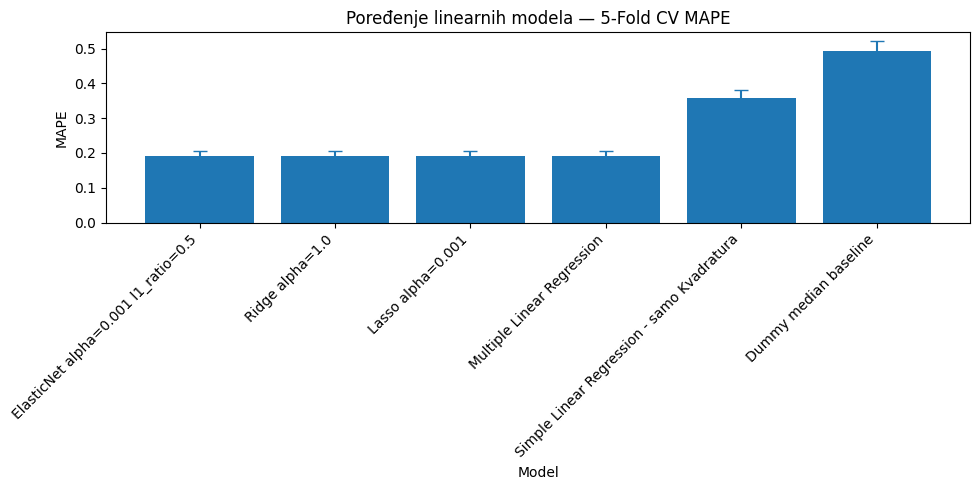

In [16]:
results = []

for name, model in models.items():
    start = time.time()
    scores = cross_val_score(model, X, y, cv=cv, scoring=mape_scorer, n_jobs=-1)
    elapsed = time.time() - start
    mape_scores = -scores
    results.append({
        'model': name,
        'MAPE_mean': mape_scores.mean(),
        'MAPE_std': mape_scores.std(),
        'MAPE_min': mape_scores.min(),
        'MAPE_max': mape_scores.max(),
        'time_sec': elapsed
    })

results_df = pd.DataFrame(results).sort_values('MAPE_mean')
display(results_df)

fig = plt.figure(figsize=(10, 5))
plt.bar(results_df['model'], results_df['MAPE_mean'])
plt.errorbar(results_df['model'], results_df['MAPE_mean'], yerr=results_df['MAPE_std'], fmt='none', capsize=5)
plt.title('Comparison of linear models — 5-Fold CV MAPE')
plt.xlabel('Model')
plt.ylabel('MAPE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 16. Tuning the Ridge regularization

Ridge regression has a hyperparameter `alpha`. It controls the strength of the L2 regularization:

- too small an `alpha` means the model is close to ordinary linear regression;
- too large an `alpha` penalizes the coefficients too much and can lead to underfitting;
- the goal is to find a value that gives the best balance between flexibility and stability.

Tuning, again, is done exclusively through cross-validation and the MAPE error.

,alpha,MAPE_mean,MAPE_std
3,0.030,0.192397,0.013046
7,3.000,0.192447,0.012286
6,1.000,0.192447,0.012970
0,0.001,0.192544,0.012709
4,0.100,0.192603,0.012993
5,0.300,0.192631,0.012831
2,0.010,0.192765,0.012883
1,0.003,0.192830,0.013285
8,10.000,0.194345,0.011149
9,30.000,0.201466,0.009724


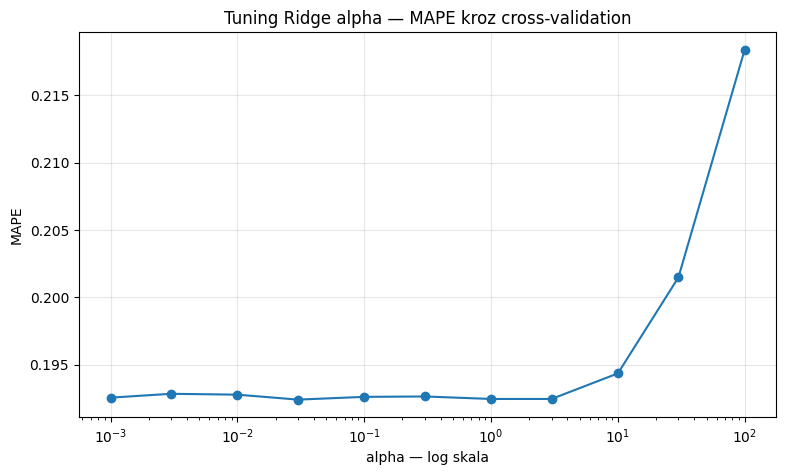

Best alpha according to CV MAPE: 0.03


In [17]:
alphas = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
alpha_results = []

for alpha in alphas:
    model = make_full_pipeline(Ridge(alpha=alpha))
    scores = cross_val_score(model, X, y, cv=cv, scoring=mape_scorer, n_jobs=-1)
    mape_scores = -scores
    alpha_results.append({
        'alpha': alpha,
        'MAPE_mean': mape_scores.mean(),
        'MAPE_std': mape_scores.std()
    })

alpha_df = pd.DataFrame(alpha_results).sort_values('MAPE_mean')
display(alpha_df)

fig = plt.figure(figsize=(9, 5))
plt.plot(alpha_df.sort_values('alpha')['alpha'], alpha_df.sort_values('alpha')['MAPE_mean'], marker='o')
plt.xscale('log')
plt.title('Tuning Ridge alpha — MAPE across cross-validation')
plt.xlabel('alpha — log scale')
plt.ylabel('MAPE')
plt.grid(True, alpha=0.3)
plt.show()

best_alpha = alpha_df.iloc[0]['alpha']
print('Best alpha according to CV MAPE:', best_alpha)

## 17. Final Ridge model

The final model uses:

- `TargetEncoder(smooth='auto')` for the high-cardinality location;
- `RobustScaler()`, since it's more resistant to the remaining outliers than standard scaling;
- `Ridge(alpha=best_alpha)` as the linear model with L2 regularization;
- `TransformedTargetRegressor` with a `log1p` / `expm1` transformation of the target.

With this approach, the model stays linear but gets higher-quality numeric inputs.

In [18]:
final_model = make_full_pipeline(Ridge(alpha=float(best_alpha)))
final_model.fit(X, y)

cv_scores_final = -cross_val_score(final_model, X, y, cv=cv, scoring=mape_scorer, n_jobs=-1)
print('Final model — CV MAPE per fold:', cv_scores_final)
print('Final model — average CV MAPE:', cv_scores_final.mean())
print('Final model — std CV MAPE:', cv_scores_final.std())

Final model — CV MAPE per fold: [0.17492894 0.18797744 0.20535435 0.20888128 0.18415536]
Final model — average CV MAPE: 0.1922594732363809
Final model — std CV MAPE: 0.012900543655343233


## 18. Cross-validation predictions for visual inspection

To visualize performance I use out-of-fold predictions: each row is predicted by a model that never saw that row during training. This gives a more honest picture of the errors than predicting on the whole training set after fitting.

In [19]:
from sklearn.base import clone

oof_pred = pd.Series(index=X.index, dtype=float)

for fold, (tr_idx, val_idx) in enumerate(cv.split(X), 1):
    model = clone(final_model)
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model.fit(X_tr, y_tr)
    oof_pred.iloc[val_idx] = model.predict(X_val)
    print(f'Fold {fold} MAPE:', mean_absolute_percentage_error(y_val, oof_pred.iloc[val_idx]))

print('OOF MAPE:', mean_absolute_percentage_error(y, oof_pred))

Fold 1 MAPE: 0.17600391323184356
Fold 2 MAPE: 0.18806551085624532
Fold 3 MAPE: 0.20628908172724567
Fold 4 MAPE: 0.20922114321785437
Fold 5 MAPE: 0.1842342124626707
OOF MAPE: 0.1927579895421863


## 19. Graphical analysis of the final model's error

These plots serve as evidence that the model not only has a good average MAPE, but also shows no obvious systematic error pattern.

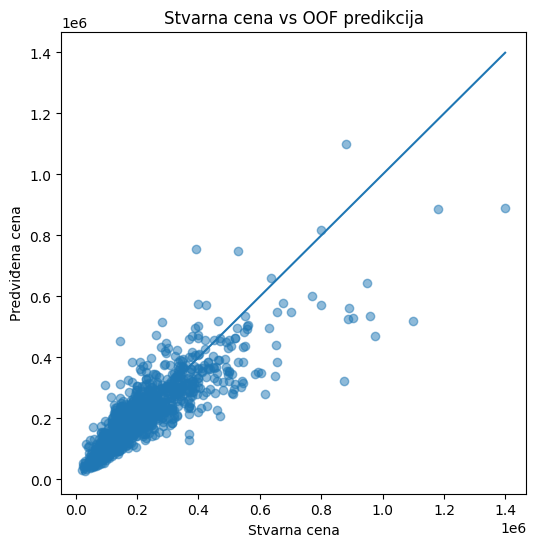

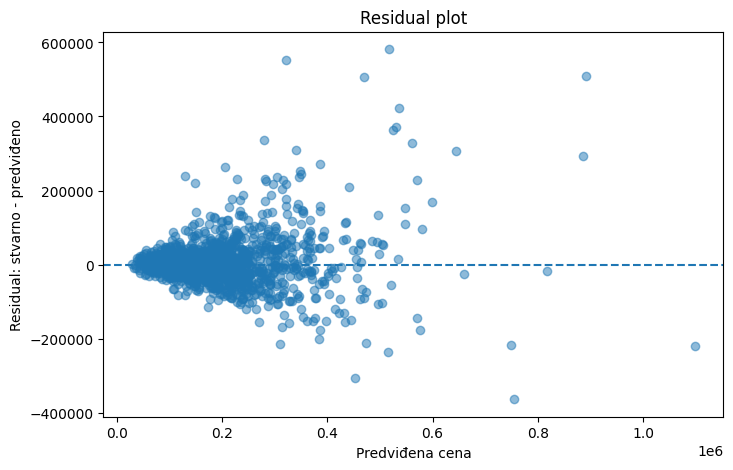

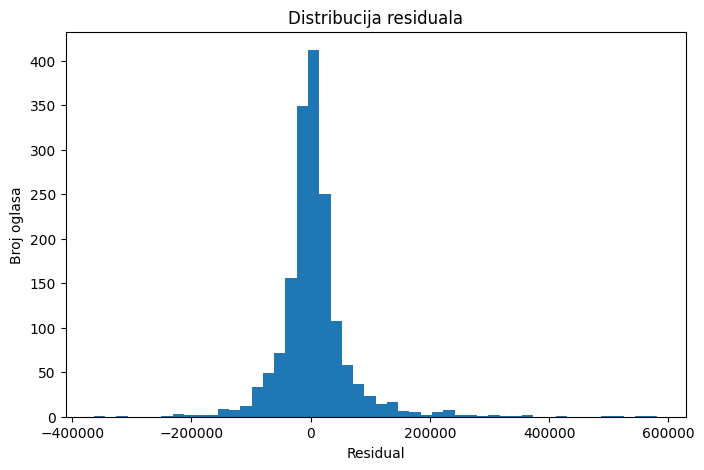

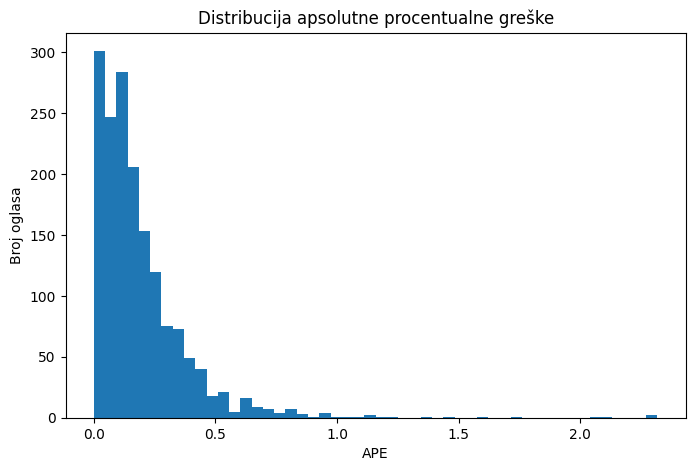

,actual,predicted,residual,APE
541,35000,116107.755308,-81107.755308,2.317364
1345,95000,310892.975282,-215892.975282,2.272558
1521,145000,452455.668333,-307455.668333,2.120384
1984,56650,172666.426279,-116016.426279,2.047951
918,48000,130643.457061,-82643.457061,1.721739
495,41500,107756.702020,-66256.702020,1.596547
1881,45000,109764.611259,-64764.611259,1.439214
1487,115000,269886.491792,-154886.491792,1.346839
366,60000,132743.560000,-72743.560000,1.212393
684,145000,314142.118360,-169142.118360,1.166497


In [20]:
residuals = y - oof_pred
ape = np.abs((y - oof_pred) / y)

fig = plt.figure(figsize=(6, 6))
plt.scatter(y, oof_pred, alpha=0.5)
min_val = min(y.min(), oof_pred.min())
max_val = max(y.max(), oof_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.title('Actual price vs OOF prediction')
plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.show()

fig = plt.figure(figsize=(8, 5))
plt.scatter(oof_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle='--')
plt.title('Residual plot')
plt.xlabel('Predicted price')
plt.ylabel('Residual: actual - predicted')
plt.show()

fig = plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50)
plt.title('Distribution of residuals')
plt.xlabel('Residual')
plt.ylabel('Number of listings')
plt.show()

fig = plt.figure(figsize=(8, 5))
plt.hist(ape, bins=50)
plt.title('Distribution of the absolute percentage error')
plt.xlabel('APE')
plt.ylabel('Number of listings')
plt.show()

error_df = pd.DataFrame({
    'actual': y,
    'predicted': oof_pred,
    'residual': residuals,
    'APE': ape
}).sort_values('APE', ascending=False)

display(error_df.head(20))

## 20. Interpreting the Ridge coefficients

Ridge is a linear model, so its coefficients can be analyzed. Since the pipeline first does encoding and scaling, extracting the names of all the features is a bit more involved. Still, this analysis gives insight into the direction and relative influence of each attribute.

,feature,coef,abs_coef
19,remainder__Grad_Subotica,-0.591253,0.591253
16,remainder__Grad_Kruševac,-0.589257,0.589257
7,remainder__Log_Kvadratura,0.440542,0.440542
17,remainder__Grad_Niš,-0.357520,0.357520
18,remainder__Grad_Novi Sad,-0.154708,0.154708
15,remainder__Je_Investitor,-0.141154,0.141154
13,remainder__Je_Prizemlje,-0.119051,0.119051
11,remainder__Renoviranje,-0.111666,0.111666
6,remainder__Parking,-0.086909,0.086909
5,remainder__Garaza,0.078136,0.078136


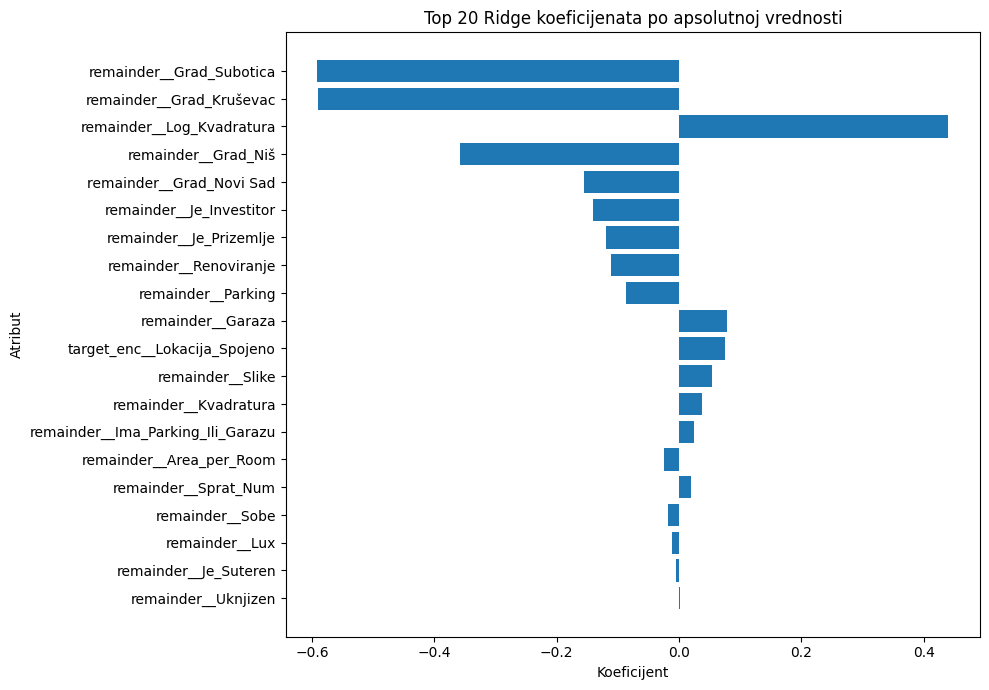

In [21]:
# The final model has already been fit. Now we try to extract the coefficients from the inner pipeline.
reg_pipeline = final_model.regressor_
preprocessor = reg_pipeline.named_steps['prep']
ridge_model = reg_pipeline.named_steps['model']

try:
    feature_names = preprocessor.get_feature_names_out()
except Exception:
    feature_names = np.array(['feature_' + str(i) for i in range(len(ridge_model.coef_))])

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': ridge_model.coef_
})
coef_df['abs_coef'] = coef_df['coef'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False)

display(coef_df.head(30))

plot_df = coef_df.head(20).iloc[::-1]
fig = plt.figure(figsize=(10, 7))
plt.barh(plot_df['feature'], plot_df['coef'])
plt.title('Top 20 Ridge coefficients by absolute value')
plt.xlabel('Coefficient')
plt.ylabel('Attribute')
plt.tight_layout()
plt.show()

## 21. Permutation importance

The coefficients are useful, but because of the scaling and transformations, I also check feature importance using permutation importance. The idea is simple: if we randomly shuffle one attribute and the MAPE gets worse, that attribute matters to the model.

,feature,importance_mean,importance_std
1,Kvadratura,0.001980,0.000551
3,Uknjizen,0.000048,0.000016
13,Je_Suteren,0.000017,0.000044
9,Lux,0.000014,0.000047
10,Renoviranje,-0.000021,0.000062
8,Ima_Parking_Ili_Garazu,-0.000169,0.000335
11,Sprat_Num,-0.000455,0.000177
14,Je_Investitor,-0.000753,0.000209
0,Slike,-0.001181,0.000730
4,Garaza,-0.001920,0.000570


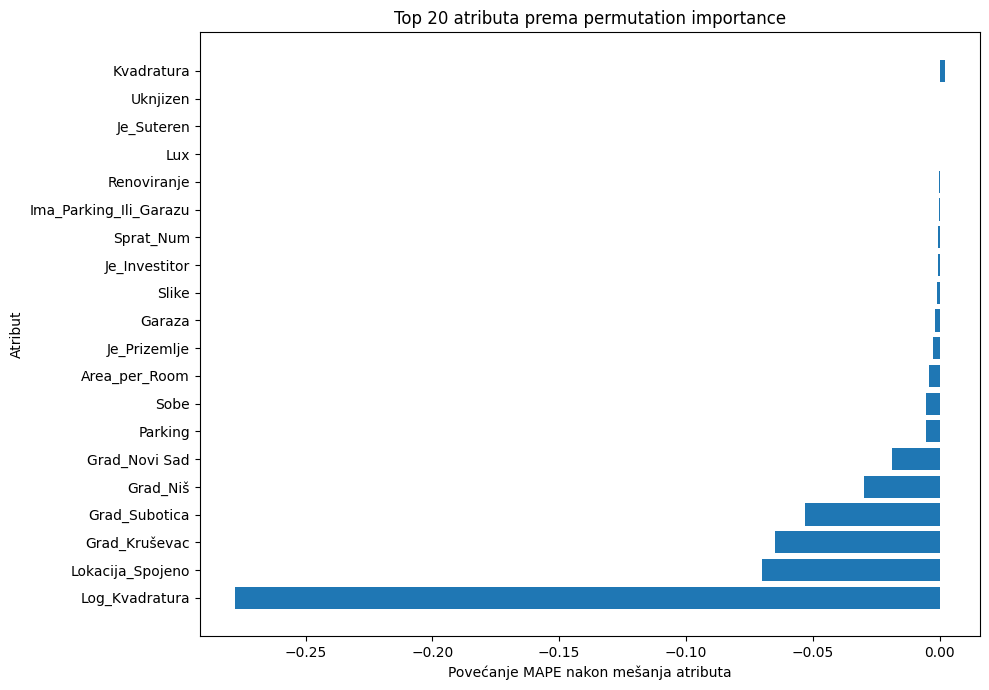

In [22]:
# Permutation importance on the training set. For a stricter estimate this could be done per fold, but this is enough for interpreting the report.
perm = permutation_importance(
    final_model, X, y,
    scoring=mape_scorer,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': -perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

display(perm_df.head(20))

plot_perm = perm_df.head(20).iloc[::-1]
fig = plt.figure(figsize=(10, 7))
plt.barh(plot_perm['feature'], plot_perm['importance_mean'])
plt.title('Top 20 attributes by permutation importance')
plt.xlabel('Increase in MAPE after shuffling the attribute')
plt.ylabel('Attribute')
plt.tight_layout()
plt.show()

## 22. Final prediction on the test set

If the test set doesn't have a `Cena` column, this cell generates predictions for submission. If it does have a price, the MAPE is also computed on the test set.

In [23]:
test_predictions = final_model.predict(X_test)

submission = pd.DataFrame({
    'Cena_predikcija': test_predictions
})

if 'Cena' in test_p.columns and test_p['Cena'].notna().any():
    y_test = to_num(test_p['Cena'])
    valid = y_test.notna()
    print('Test MAPE:', mean_absolute_percentage_error(y_test[valid], test_predictions[valid]))

submission.to_csv('predikcije_ridge.csv', index=False)
display(submission.head())
print('Saved file: predikcije_ridge.csv')

Test MAPE: 0.518922041527942


,Cena_predikcija
0,151464.673955
1,76420.949518
2,310884.909946
3,102293.031982
4,108444.988220


Saved file: predikcije_ridge.csv


## 23. Conclusion for the report

Based on the results shown, the final choice is Ridge regression with Target Encoding, a RobustScaler, and a log-transformation of the target variable. This solution is reached step by step:

1. The EDA shows that the price is strongly skewed and that outliers exist.
2. Log-transforming the target stabilizes the price distribution.
3. Outlier filters reduce the influence of unrealistic listings.
4. Feature engineering extracts additional information from the floor area, number of rooms, floor, parking, seller, and listing title.
5. Target Encoding allows the high-cardinality location to be used in a linear model without creating hundreds of dummy columns.
6. Cross-validation using the MAPE error shows which linear model generalizes best.
7. Ridge tuning confirms the optimal regularization strength.

The model stays linear, but it gets high-quality numeric inputs and a more stable target, which is why it achieves a better MAPE than the simple and the plain multiple linear regression.